In [4]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import zscore

# ─────────────────────────────────────────────
# CONFIG – adjust paths to your local structure
# ─────────────────────────────────────────────
SUBJECT_IDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
DATA_ROOT   = "WESAD"           # relative to the notebook / working directory
E4_EDA_HZ   = 4                         # E4 EDA sample rate

LABEL_MAP = {
    0: "Transient / Undefined",
    1: "Baseline",
    2: "Stress",
    3: "Amusement",
    4: "Meditation",
    5: "Ignore",
    6: "Ignore",
    7: "Ignore",
}
LABEL_COLORS = {
    0: "#888888", 1: "#4CAF50", 2: "#F44336",
    3: "#2196F3", 4: "#9C27B0", 5: "#AAAAAA",
    6: "#AAAAAA", 7: "#AAAAAA",
}

/var/folders/3t/6rlgpcs12rb84pq6mh6cfr680000gn/T/ipykernel_80936/1075279155.py:9: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  subjects[sid] = pickle.load(f, encoding="latin1")


  Loaded S2
  Loaded S3
  Loaded S4
  Loaded S5
  Loaded S6
  Loaded S7
  Loaded S8
  Loaded S9
  Loaded S10
  Loaded S11
  Loaded S13
  Loaded S14
  Loaded S15
  Loaded S16
  Loaded S17

[1] Class distribution across all subjects …


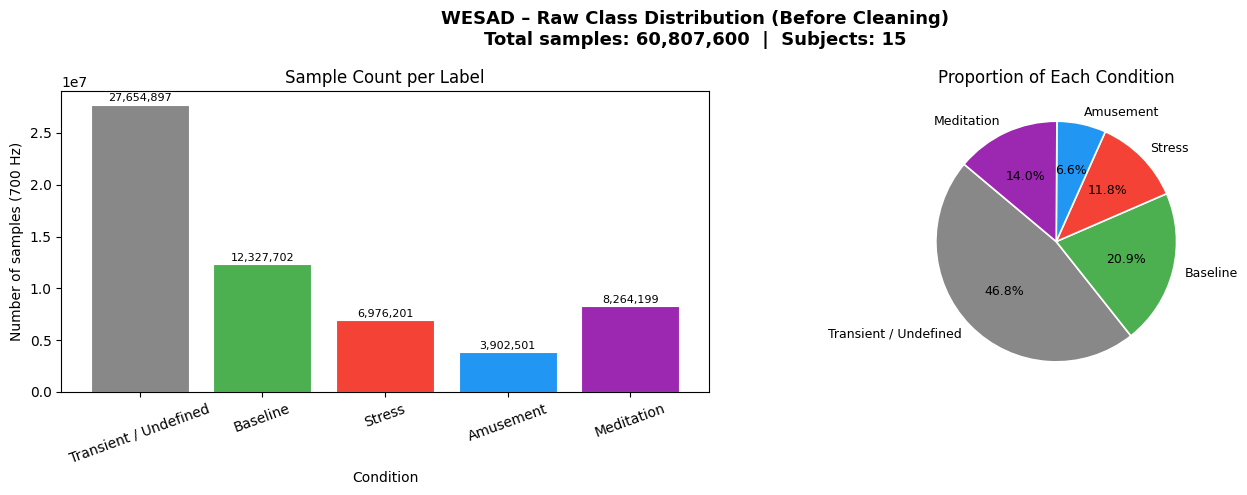

  → Saved viz1_class_distribution.png

[2] Raw EDA signal with condition overlay for S3 …


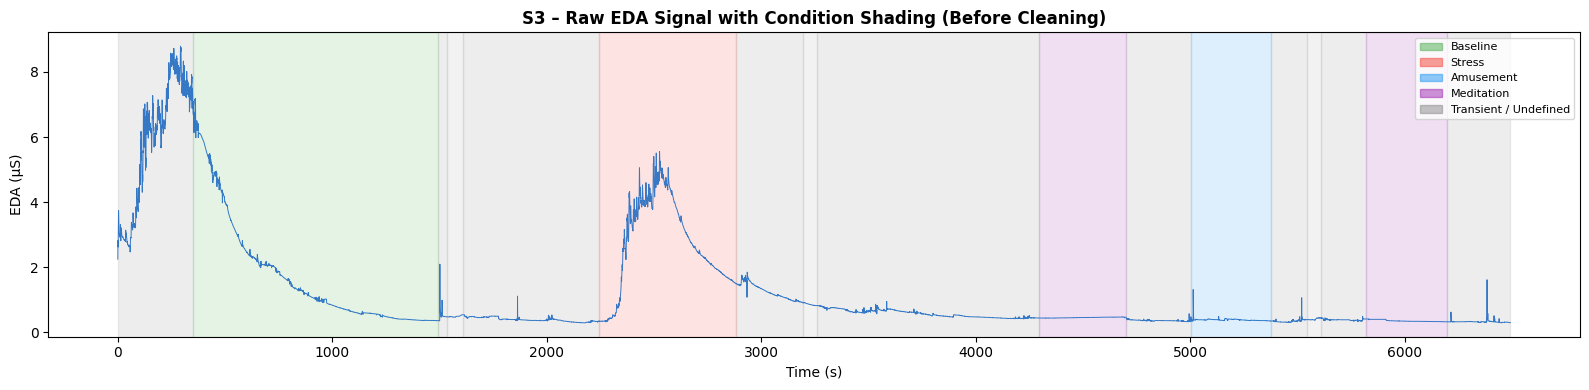

  → Saved viz2_S3_raw_eda_overlay.png

[3] EDA distribution across conditions (all subjects) …


/var/folders/3t/6rlgpcs12rb84pq6mh6cfr680000gn/T/ipykernel_80936/1075279155.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Condition", y="EDA (µS)", order=condition_order,
/var/folders/3t/6rlgpcs12rb84pq6mh6cfr680000gn/T/ipykernel_80936/1075279155.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_plot, x="Condition", y="EDA (µS)", order=condition_order,


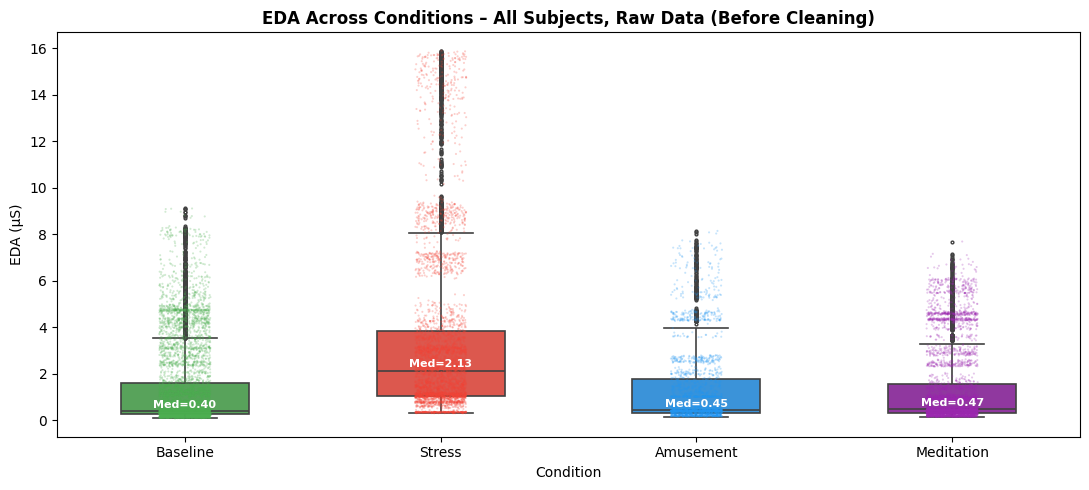

  → Saved viz3_eda_across_conditions.png


In [5]:


# ─────────────────────────────────────────────
# LOAD all subjects from .pkl
# ─────────────────────────────────────────────
subjects = {}
for sid in SUBJECT_IDS:
    pkl_path = f"{DATA_ROOT}/S{sid}/S{sid}.pkl"
    try:
        with open(pkl_path, "rb") as f:
            subjects[sid] = pickle.load(f, encoding="latin1")
        print(f"  Loaded S{sid}")
    except FileNotFoundError:
        print(f"  MISSING S{sid}, skipping")


# ══════════════════════════════════════════════════════════════════
# VISUALIZATION 1 – Class Distribution (raw, before cleaning)
# ══════════════════════════════════════════════════════════════════
print("\n[1] Class distribution across all subjects …")

all_labels = []
for sid, data in subjects.items():
    labels = data["label"]          # 1-D numpy array, sampled at 700 Hz (chest)
    all_labels.append(labels)

all_labels_flat = np.concatenate(all_labels)

# Count only the 5 meaningful labels
valid_labels = [0, 1, 2, 3, 4]
counts = {l: int(np.sum(all_labels_flat == l)) for l in valid_labels}
label_names  = [LABEL_MAP[l] for l in valid_labels]
label_counts = [counts[l] for l in valid_labels]
colors       = [LABEL_COLORS[l] for l in valid_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("WESAD – Raw Class Distribution (Before Cleaning)\n"
             f"Total samples: {all_labels_flat.size:,}  |  Subjects: {len(subjects)}",
             fontsize=13, fontweight="bold")

# Bar chart
bars = axes[0].bar(label_names, label_counts, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Sample Count per Label")
axes[0].set_ylabel("Number of samples (700 Hz)")
axes[0].set_xlabel("Condition")
axes[0].tick_params(axis="x", rotation=20)
for bar, cnt in zip(bars, label_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{cnt:,}", ha="center", va="bottom", fontsize=8)

# Pie chart – highlight class imbalance
wedge_props = dict(edgecolor="white", linewidth=1.2)
axes[1].pie(label_counts, labels=label_names, colors=colors,
            autopct="%1.1f%%", startangle=140,
            wedgeprops=wedge_props, textprops={"fontsize": 9})
axes[1].set_title("Proportion of Each Condition")

plt.tight_layout()
plt.savefig("viz1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Saved viz1_class_distribution.png")


# ══════════════════════════════════════════════════════════════════
# VISUALIZATION 2 – Raw EDA signal + label overlay (one subject)
# ══════════════════════════════════════════════════════════════════
DEMO_SUBJECT = 3          # change to any loaded subject
print(f"\n[2] Raw EDA signal with condition overlay for S{DEMO_SUBJECT} …")

data   = subjects[DEMO_SUBJECT]
eda    = data["signal"]["wrist"]["EDA"].flatten()   # 4 Hz
labels = data["label"]                              # 700 Hz

# Down-sample labels to 4 Hz to match EDA
ds_factor   = 700 // E4_EDA_HZ          # = 175
labels_4hz  = labels[::ds_factor][: len(eda)]
time_sec    = np.arange(len(eda)) / E4_EDA_HZ

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(time_sec, eda, color="#1565C0", linewidth=0.7, alpha=0.85, label="EDA (µS)")

# Shade background by condition
prev_lbl, prev_t = labels_4hz[0], 0.0
for i, lbl in enumerate(labels_4hz):
    if lbl != prev_lbl or i == len(labels_4hz) - 1:
        t_now = i / E4_EDA_HZ
        ax.axvspan(prev_t, t_now,
                   color=LABEL_COLORS.get(prev_lbl, "#888888"),
                   alpha=0.15)
        prev_lbl, prev_t = lbl, t_now

ax.set_title(f"S{DEMO_SUBJECT} – Raw EDA Signal with Condition Shading (Before Cleaning)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Time (s)")
ax.set_ylabel("EDA (µS)")

legend_patches = [mpatches.Patch(color=LABEL_COLORS[l], label=LABEL_MAP[l], alpha=0.5)
                  for l in [1, 2, 3, 4, 0]]
ax.legend(handles=legend_patches, loc="upper right", fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig(f"viz2_S{DEMO_SUBJECT}_raw_eda_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  → Saved viz2_S{DEMO_SUBJECT}_raw_eda_overlay.png")


# ══════════════════════════════════════════════════════════════════
# VISUALIZATION 3 – EDA distribution across conditions (box + strip)
# ══════════════════════════════════════════════════════════════════
print("\n[3] EDA distribution across conditions (all subjects) …")

records = []
for sid, data in subjects.items():
    eda    = data["signal"]["wrist"]["EDA"].flatten()
    labels = data["label"]
    ds_factor  = 700 // E4_EDA_HZ
    labels_4hz = labels[::ds_factor][: len(eda)]

    for lbl in [1, 2, 3, 4]:           # skip transient/noise labels
        mask = labels_4hz == lbl
        eda_seg = eda[mask]
        if len(eda_seg) == 0:
            continue
        for val in eda_seg[::10]:       # thin out for plot performance
            records.append({"Condition": LABEL_MAP[lbl], "EDA (µS)": val, "Subject": f"S{sid}"})

df_plot = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(11, 5))
condition_order = ["Baseline", "Stress", "Amusement", "Meditation"]
palette = {LABEL_MAP[1]: LABEL_COLORS[1], LABEL_MAP[2]: LABEL_COLORS[2],
           LABEL_MAP[3]: LABEL_COLORS[3], LABEL_MAP[4]: LABEL_COLORS[4]}

sns.boxplot(data=df_plot, x="Condition", y="EDA (µS)", order=condition_order,
            palette=palette, width=0.5, fliersize=2, linewidth=1.2, ax=ax)
sns.stripplot(data=df_plot, x="Condition", y="EDA (µS)", order=condition_order,
              palette=palette, size=1.5, alpha=0.25, jitter=True, ax=ax)

ax.set_title("EDA Across Conditions – All Subjects, Raw Data (Before Cleaning)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Condition")
ax.set_ylabel("EDA (µS)")

# Annotate with median values
for i, cond in enumerate(condition_order):
    med = df_plot[df_plot["Condition"] == cond]["EDA (µS)"].median()
    ax.text(i, med + 0.05, f"Med={med:.2f}", ha="center", va="bottom",
            fontsize=8, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig("viz3_eda_across_conditions.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Saved viz3_eda_across_conditions.png")